In [1]:
%reload_ext autoreload
%pylab inline
%autoreload 2
import numpy as np
from os.path import join
import sys
sys.path.insert(0, '/home/did/RTC/SMART-G/smartg/tools/')
from luts import MLUT, Idx, read_mlut
from smacg import Smacg, get_smac_coeffs
import xarray
from datetime import datetime
from netCDF4 import Dataset

Populating the interactive namespace from numpy and matplotlib


In [2]:
# path to DEM
fdem = '/rfs/data/DEM/GTOPO30_DZ_MLUT.nc' 
# DEM Read (once!)
dem_lut = read_mlut(fdem) # global DEM GTOPO 30, reading once, could be long, stored into a MLUT object
# dem object is a MLUT object
dem_lut.describe()

 Datasets:
  [0] elev (int16 in [-500, 8.75e+03]), axes=('lat', 'lon')
  [1] Delev (uint16 in [0, 1.28e+03]), axes=('lat', 'lon')
 Axes:
  [0] lat: 21600 values in [90.0, -90.0]
  [1] lon: 43200 values in [-180.0, 180.0]


In [3]:
def Ps(z,p0,T, g=9.801, R=287.058, lam=-0.006):
    T1 = np.log(R*T) - np.log(-R*lam*z+R*T)
    return p0*np.exp(-g/(R*lam)*T1) 
def dPsdz(z,p0,T, g=9.801, R=287.058, lam=-0.006):
    return g*Ps(z,p0,T, g=9.801, R=287.058, lam=-0.006)/(R*(T-lam*z))

# SMACG configuration

In [4]:
# path to input VGT image (format hdf5)
path   = '/rfs/data/C3S/VGT/EXTRACT/'
fname_i= '1999/19990601/11_Ispra_V119990601138.h5'
fname_o= '1999/19990601/11_Ispra_V119990601138_toc.nc'
fname  = path + fname_i
year   = fname[26:30]
date   = fname[31:39]

# path to input ancillary MERRA 2 data
# 1) aerosols
merra_aerosol='/rfs/data/MERRA2/aer_extinction/'+year+'/MERRA2_200.tavg1_2d_aer_Nx.'+date+'.SUB.nc4'
# 2) PTWO, Pressure, Temperature, Water vapour ,Ozone
merra_ptwo='/rfs/data/MERRA2/surf_pression_water_vapor/'+year+'/MERRA2_200.tavg1_2d_slv_Nx.'+date+'.SUB.nc4'

# GPU grid
XBLOCK = 32
XGRID  = 32
YGRID  = 1
YBLOCK = 1

NBLOOP = 1   # eventually loops within card (for first version of smacg NLOOP=1)

sensor   = 'VGT1'  # Effective sensor
aer_coef = 'CONT'  # 'CONT' or 'DES' SMAC aerosol coefficient
tab_band_internal = ['B0', 'B2', 'B3', 'MIR']  # List bands here
tab_band = ['B0', 'B2', 'B3', 'MIR']  # List bands here
NB = len(tab_band)  # number of bands
dir_coef_name = './' # directory containing SMAC Coefficients

### Constants
k_uh2o = 1e-1  # conversion from kg.m-2 to g.cm-2
k_uo3  = 1e-3  # (for MERRA-2, Dobson) to cm.atm
k_p0   = 1e-2  # pascal to hectopascal

# Error budget 
Etoa   = 0    # Should come form level 1 file
ERtoa  = 0.01 # precision toa reflectance (in %)

Etaup  = 0.05 # see ATBD for post 2000 era
ERtaup = 0.15

Euo3   = 0.0
ERuo3  = 0.06 # According to Wargan et al., 2017, see ATBD

Euh2o  = 0.0
ERuh2o = 0.2  # see  Davis et al., 2017, see ATBD, no clear numbers, TBC

Epre   = 1.0  # pure meteorological uncertainy (hPa)
ERpre  = 0.0  # TBC see ATBD
  
# compile Smacg 
S=Smacg()

#  VGT preprocessing

In [5]:
from scipy.interpolate import RectBivariateSpline

def get_meantime(dataset):
    date = dataset.segm_first_date
    time = dataset.segm_first_time
    dt1  = np.datetime64(str(date[:4]) + '-' + str(date[4:6]) + \
                        '-' + str(date[6:])+ 'T' +  str(time[:2]) + \
                         ':' + str(time[2:4])+ ':' + str(time[4:]))
    time = dataset.segm_last_time
    dt2  = np.datetime64(str(date[:4]) + '-' + str(date[4:6]) + \
                        '-' + str(date[6:])+ 'T' +  str(time[:2]) + \
                         ':' + str(time[2:4])+ ':' + str(time[4:]))

    return ((dt2-dt1)/2. +dt1)

def datetime2year(dt): 
    year_part = dt - datetime(year=dt.year, month=1, day=1)
    year_length = datetime(year=dt.year+1, month=1, day=1) - datetime(year=dt.year, month=1, day=1)
    return dt.year + year_part/year_length

def to_float (dataset, elem):
    res = dataset[elem] = dataset[elem] * float(dataset[elem].attrs['Scale']) + float(dataset[elem].attrs['Offset'])
    return res

def date_to_float(d, epoch=numpy.datetime64('1980-01-01T00:00:00.000000000')):
    '''
    transform the date into a duration in minutes since epoch
    '''
    return (d - epoch).astype(float64)/1.0e9/60.

def pre(fname):
    dataset = xarray.open_dataset(fname)
    
    SIZE1, SIZE2 = dataset['B0'].shape
    XTIE, YTIE   = dataset['SZA'].shape
    lon0, lat0, d_lon, d_lat = [float(x) for x in dataset.map_info.split(',')[3:7]]

    lat=lat0 - arange(SIZE1)*d_lat
    lon=lon0 + arange(SIZE2)*d_lon
    lon,lat=np.meshgrid(lon,lat)
    dataset['lat']=(('x', 'y'), lat)
    dataset['lon']=(('x', 'y'), lon)
     
    # preprocessing of VGT file to fill lat and lon to XSIZE and YSIZE
    # This maybe unnecessary in the future if lat and lon are given for each pixel of VGT
    VGT_TIE_COMPLETE(dataset,'SZA', (SIZE1,SIZE2), (XTIE,YTIE))
    VGT_TIE_COMPLETE(dataset,'SAA', (SIZE1,SIZE2), (XTIE,YTIE))
    VGT_TIE_COMPLETE(dataset,'VZA', (SIZE1,SIZE2), (XTIE,YTIE))
    VGT_TIE_COMPLETE(dataset,'VAA', (SIZE1,SIZE2), (XTIE,YTIE))
    
    # scale reflectances
    to_float(dataset,'B0')
    to_float(dataset,'B2')
    to_float(dataset,'B3')
    to_float(dataset,'MIR')
    
    # mean decimal time for the scene
    dataset['mean-time']= get_meantime(dataset)
    dataset['mean-time-dec']= date_to_float(dataset['mean-time'])
    
    return dataset, SIZE1, SIZE2


def VGT_TIE_COMPLETE (dataset,a, size, tie):
    SIZE1, SIZE2 = size
    XTIE, YTIE = tie
    ref = dataset[a] * float(dataset[a].attrs['Scale']) + float(dataset[a].attrs['Offset'])
    r1=np.arange(0,SIZE1,XTIE)
    r11,_=np.meshgrid(np.arange(SIZE1),np.arange(SIZE2))
    r2=np.arange(0,SIZE2,YTIE)
    _,r22=np.meshgrid(np.arange(SIZE1),np.arange(SIZE2))
    res = RectBivariateSpline(r1,r2,ref).ev(r11,r22)
    res = xarray.DataArray(res,dims = ('phony_dim_0', 'phony_dim_0'))    
    dataset.drop(a)
    dataset[a] = res

vgt_data, SIZE1, SIZE2 = pre(fname)

# MERRA2 preprocessing

In [6]:
# Read MERRA2 ancillary data files and store all information into a MLUT object for further use
# (mainly for spatial and temporal interpolation)
merra = xarray.open_dataset(merra_aerosol)
merra_lut = MLUT()
# Add the good axis
merra_lut.add_axis('time', date_to_float(merra.time.data)) # float array of delta time in ns from epoch time
merra_lut.add_axis('lat',  merra.lat.data)
merra_lut.add_axis('lon',  merra.lon.data)
merra_lut.add_dataset('TOTEXTTAU', merra['TOTEXTTAU'].data, axnames=['time','lat','lon'])

merra = xarray.open_dataset(merra_ptwo)
merra_lut.add_dataset('TO3',  merra['TO3'].data,  axnames=['time','lat','lon'])
merra_lut.add_dataset('SLP',  merra['SLP'].data,  axnames=['time','lat','lon'])
merra_lut.add_dataset('T10M', merra['T10M'].data, axnames=['time','lat','lon'])
merra_lut.add_dataset('TQV',  merra['TQV'].data,  axnames=['time','lat','lon'])

# MLUT object description
merra_lut.describe()

 Datasets:
  [0] TOTEXTTAU (float64 in [0.00475, 2.75]), axes=('time', 'lat', 'lon')
  [1] TO3 (float64 in [206, 434]), axes=('time', 'lat', 'lon')
  [2] SLP (float64 in [9.45e+04, 1.04e+05]), axes=('time', 'lat', 'lon')
  [3] T10M (float64 in [199, 322]), axes=('time', 'lat', 'lon')
  [4] TQV (float64 in [0.106, 82]), axes=('time', 'lat', 'lon')
 Axes:
  [0] time: 24 values in [10211070.0, 10212450.0]
  [1] lat: 361 values in [-90.0, 90.0]
  [2] lon: 576 values in [-180.0, 179.375]


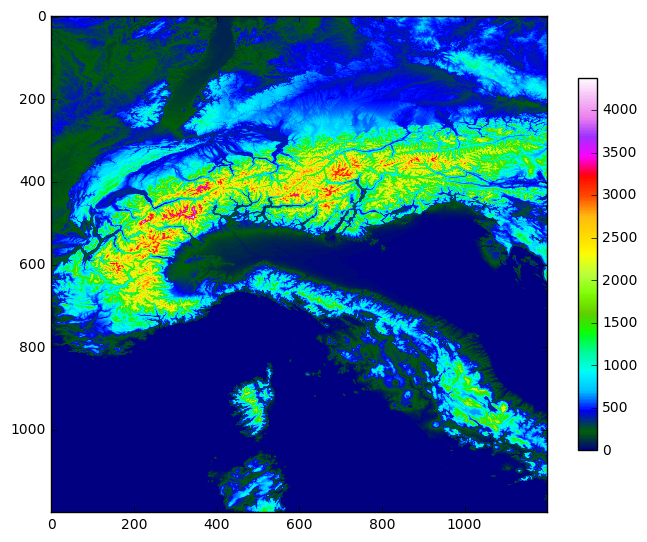

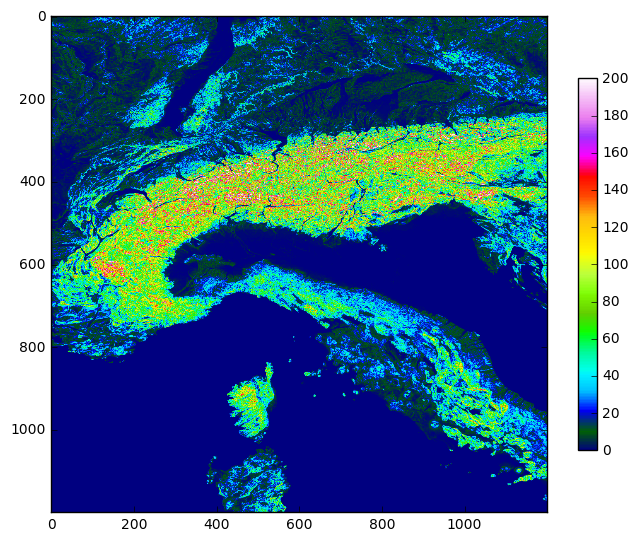

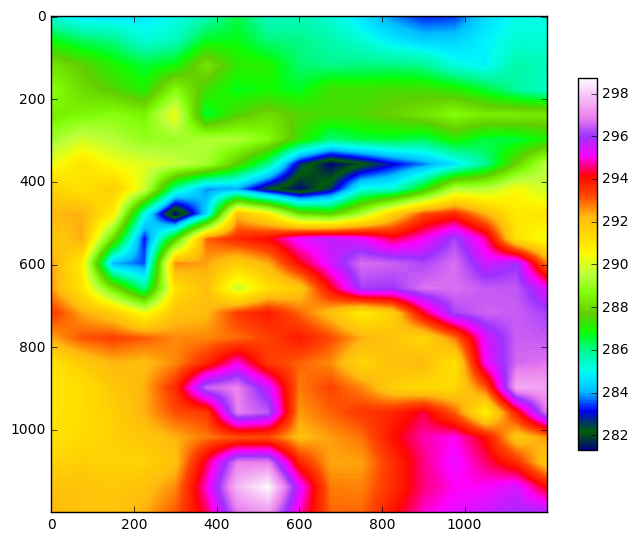

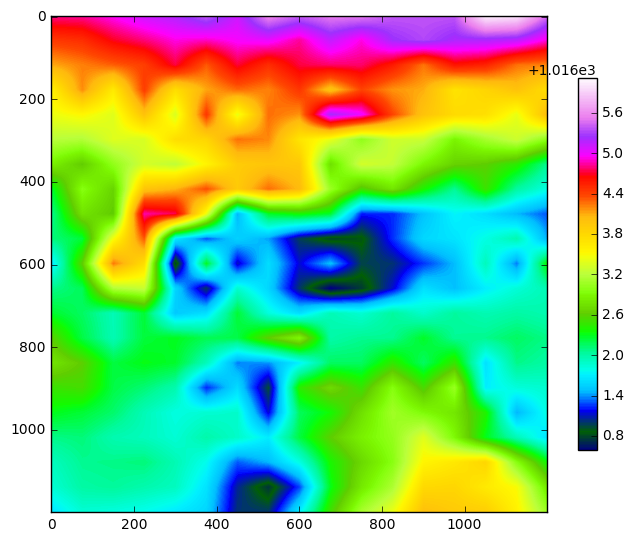

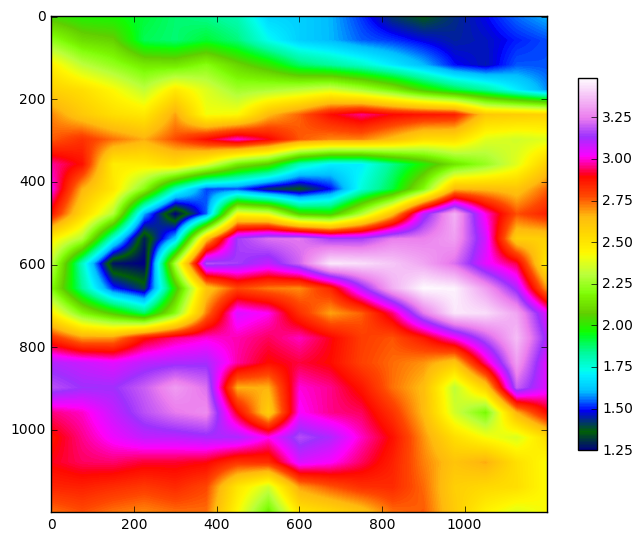

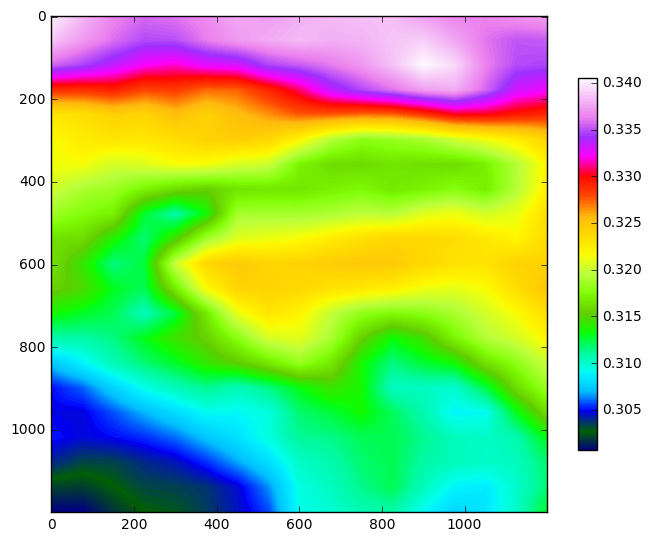

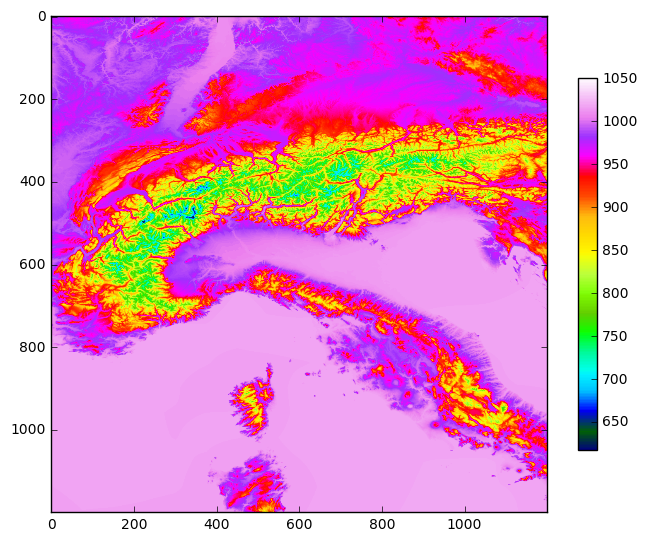

In [7]:
if True:
    lon2,lat2=np.meshgrid(np.linspace(5.,15.,num=1200),np.linspace(50.,40.,num=1200))
    z=dem_lut['elev'][Idx(lat2),Idx(lon2)]
    z[np.where(z<=0)]=0.
    figure(figsize=(8,8))
    imshow(z,cmap='gist_ncar')
    colorbar(shrink=0.6)
    figure(figsize=(8,8))
    imshow(dem_lut['Delev'][Idx(lat2),Idx(lon2)], vmax=200,cmap='gist_ncar')
    colorbar(shrink=0.6)
    figure(figsize=(8,8))
    imshow(merra_lut['T10M'].sub({'time':0})[Idx(lat2),Idx(lon2)], cmap='gist_ncar')
    colorbar(shrink=0.6)
    figure(figsize=(8,8))
    imshow(merra_lut['SLP'].sub({'time':0})[Idx(lat2),Idx(lon2)]/100, cmap='gist_ncar')
    colorbar(shrink=0.6)
    figure(figsize=(8,8))
    imshow(merra_lut['TQV'].sub({'time':0})[Idx(lat2),Idx(lon2)]*k_uh2o, cmap='gist_ncar')
    colorbar(shrink=0.6)
    figure(figsize=(8,8))
    imshow(merra_lut['TO3'].sub({'time':0})[Idx(lat2),Idx(lon2)]*k_uo3, cmap='gist_ncar')
    colorbar(shrink=0.6)
    T10M=merra_lut['T10M'].sub({'time':0})[Idx(lat2),Idx(lon2)]
    P0=merra_lut['SLP'].sub({'time':0})[Idx(lat2),Idx(lon2)]/100
    figure(figsize=(8,8))
    PS = Ps(z,P0,T10M)
    imshow(PS, vmax=1050, cmap='gist_ncar')
    colorbar(shrink=0.6)

# SMAC-G preparation of data

In [8]:
# files containg SMAC coefficients
bands_path = ["".join((dir_coef_name, 'COEFFS/coef_' + sensor + '_' + str(x) + '_' + aer_coef + '.dat')) for x in tab_band]

# masking cloudy & out of orbit pixels and SZA above 90°
SM   = vgt_data['SM'].data
SZA  = vgt_data['SZA'].data
good = np.where(((SM&1 == 0) & (SM&2 == 0) & (SM&4 == 0)) & (SZA < 90))
GSIZE= good[0].size

# start with tie points
tetas       = vgt_data['SZA'].data[good].astype(float32, order='C')
tetav       = vgt_data['VZA'].data[good].astype(float32, order='C')
phis        = vgt_data['SAA'].data[good].astype(float32, order='C')
phiv        = vgt_data['VAA'].data[good].astype(float32, order='C')
                                   
lat         = vgt_data['lat'].data[good]
lon         = vgt_data['lon'].data[good]
t0          = vgt_data['mean-time-dec'].data

#interpolate merra 2 data to the image location and time
taup550     = merra_lut['TOTEXTTAU']\
                [Idx(t0,  round=False, fill_value='extrema'), \
                 Idx(lat, round=False, fill_value='extrema'), \
                 Idx(lon, round=False, fill_value='extrema')] \
                .astype(float32, order='C') 
uh2o        = merra_lut['TQV']\
                [Idx(t0,  round=False, fill_value='extrema'), \
                 Idx(lat, round=False, fill_value='extrema'), \
                 Idx(lon, round=False, fill_value='extrema')] \
                .astype(float32, order='C') 
uo3         = merra_lut['TO3']\
                [Idx(t0,  round=False, fill_value='extrema'), \
                 Idx(lat, round=False, fill_value='extrema'), \
                 Idx(lon, round=False, fill_value='extrema')] \
                .astype(float32, order='C') 
p0          = merra_lut['SLP']\
                [Idx(t0,  round=False, fill_value='extrema'), \
                 Idx(lat, round=False, fill_value='extrema'), \
                 Idx(lon, round=False, fill_value='extrema')] \
                .astype(float32, order='C') 
t10m        = merra_lut['T10M']\
                [Idx(t0,  round=False, fill_value='extrema'), \
                 Idx(lat, round=False, fill_value='extrema'), \
                 Idx(lon, round=False, fill_value='extrema')] \
                .astype(float32, order='C') 
#interpolate DEM and uncertainty to the image location and time
alt         = dem_lut['elev']\
                [Idx(lat, round=False, fill_value='extrema'), \
                 Idx(lon, round=False, fill_value='extrema')] \
                .astype(float32, order='C') 
Dalt        = dem_lut['Delev']\
                [Idx(lat, round=False, fill_value='extrema'), \
                 Idx(lon, round=False, fill_value='extrema')] \
                .astype(float32, order='C') 
# pressure correction for surface altitude and transformation from Pa to hPa
pressure = Ps(alt, p0*k_p0, t10m)
# quadratic mean of error due to met fields (Epre) and error due to altitude (Dalt)
pressure_err = np.sqrt((dPsdz(alt, p0*k_p0, t10m) * Dalt)**2 + Epre**2)/2.
# conversion from kg.m-2 to g.cm-2
uh2o *= k_uh2o
# conversion from Dobson to cm.atm 
uo3  *= k_uo3

# prepare radiometry array
rtoa        = np.zeros((NB, GSIZE), dtype='float32', order='C')
rtoa_err    = np.zeros((NB, GSIZE), dtype='float32', order='C')
for iband, band in enumerate(tab_band_internal):
    rtoa[iband,:]     = vgt_data[band].data[good]
# error on toa reflectance should come with level 1 : here computation
rtoa_err= Etoa + ERtoa * rtoa

## Input arrays resizing to adapt to GPU grid size
#
# number of planes in the 3rd dimension to be created
Z = int(math.ceil(float(GSIZE)/float(XBLOCK*XGRID)))
GSIZEXT = Z * XBLOCK * XGRID

# the "ext" suffix is for extended arrays, larger than the good pixels size, it is completed by NaN's
rtoa_ext     = np.zeros((NB, GSIZEXT), dtype='float32') + np.NaN
taup550_ext  = np.zeros((GSIZEXT), dtype='float32') + np.NaN
uo3_ext      = np.zeros((GSIZEXT), dtype='float32') + np.NaN
pressure_ext = np.zeros((GSIZEXT), dtype='float32') + np.NaN
uh2o_ext     = np.zeros((GSIZEXT), dtype='float32') + np.NaN
tetas_ext    = np.zeros((GSIZEXT), dtype='float32') + np.NaN
tetav_ext    = np.zeros((GSIZEXT), dtype='float32') + np.NaN
phis_ext     = np.zeros((GSIZEXT), dtype='float32') + np.NaN
phiv_ext     = np.zeros((GSIZEXT), dtype='float32') + np.NaN
for i in range(NB):
    rtoa_ext[i,:GSIZE] = rtoa[i,:]
taup550_ext[:GSIZE]  = taup550
uo3_ext[:GSIZE]      = uo3
pressure_ext[:GSIZE] = pressure
uh2o_ext[:GSIZE]     = uh2o
tetas_ext[:GSIZE]    = tetas
tetav_ext[:GSIZE]    = tetav
phis_ext[:GSIZE]     = phis
phiv_ext[:GSIZE]     = phiv

# Getting SMAC coefficients
coeffs     = get_smac_coeffs(bands_path)

# Processing by the GPU

In [9]:
%%time
# Input arrays reshaping
rtoa_ext     = np.reshape(rtoa_ext,    (NB,Z,XBLOCK,XGRID), order='C')
tetas_ext    = np.reshape(tetas_ext,   (Z,XBLOCK,XGRID),    order='C')
tetav_ext    = np.reshape(tetav_ext,   (Z,XBLOCK,XGRID),    order='C')
phis_ext     = np.reshape(phis_ext,    (Z,XBLOCK,XGRID),    order='C')
phiv_ext     = np.reshape(phiv_ext,    (Z,XBLOCK,XGRID),    order='C')
uh2o_ext     = np.reshape(uh2o_ext,    (Z,XBLOCK,XGRID),    order='C')
uo3_ext      = np.reshape(uo3_ext,     (Z,XBLOCK,XGRID),    order='C')
taup550_ext  = np.reshape(taup550_ext, (Z,XBLOCK,XGRID),    order='C')
pressure_ext = np.reshape(pressure_ext,(Z,XBLOCK,XGRID),    order='C')

# Run
(rsurf_ext,Jrtoa_ext,Juo3_ext,Juh2o_ext,Jpre_ext,Jtaup_ext) = S.run(coeffs, tetas_ext, tetav_ext, 
        phis_ext, phiv_ext, uh2o_ext, uo3_ext, taup550_ext, pressure_ext, rtoa_ext,
        XBLOCK=XBLOCK, XGRID=XGRID, NBLOOP=NBLOOP)

# Output arrays reshaping 
rsurf_ext = np.reshape(rsurf_ext,(NB,GSIZEXT), order='C')
Jrtoa_ext = np.reshape(Jrtoa_ext,(NB,GSIZEXT), order='C')
Juo3_ext  = np.reshape(Juo3_ext, (NB,GSIZEXT), order='C')
Juh2o_ext = np.reshape(Juh2o_ext,(NB,GSIZEXT), order='C')
Jpre_ext  = np.reshape(Jpre_ext, (NB,GSIZEXT), order='C')
Jtaup_ext = np.reshape(Jtaup_ext,(NB,GSIZEXT), order='C')

CPU times: user 58.2 ms, sys: 147 ms, total: 206 ms
Wall time: 517 ms


# Post Processing for uncertainties and output writing

In [10]:
rsurf  = np.zeros((NB,SIZE1,SIZE2))
Drsurf = np.zeros((NB,SIZE1,SIZE2))
inter  = np.zeros((SIZE1,SIZE2)) + np.nan
stock  = np.zeros((GSIZE))
BREAKPOINT = True
INPUT      = True

if BREAKPOINT :
    Jrtoa  = np.zeros((NB,SIZE1,SIZE2))
    Juo3   = np.zeros((NB,SIZE1,SIZE2))
    Juh2o  = np.zeros((NB,SIZE1,SIZE2))
    Jpre   = np.zeros((NB,SIZE1,SIZE2))
    Jtaup  = np.zeros((NB,SIZE1,SIZE2))
    Drtoa  = np.zeros((NB,SIZE1,SIZE2))
    Duo3   = np.zeros((NB,SIZE1,SIZE2))
    Duh2o  = np.zeros((NB,SIZE1,SIZE2))
    Dpre   = np.zeros((NB,SIZE1,SIZE2))
    Dtaup  = np.zeros((NB,SIZE1,SIZE2))
    
if INPUT :
    Irtoa  = np.zeros((NB,SIZE1,SIZE2))
    Iuo3   = np.zeros((SIZE1,SIZE2)) + np.nan
    Iuh2o  = np.zeros((SIZE1,SIZE2)) + np.nan
    Ipre   = np.zeros((SIZE1,SIZE2)) + np.nan
    Itaup  = np.zeros((SIZE1,SIZE2)) + np.nan
    Ialt   = np.zeros((SIZE1,SIZE2)) + np.nan
    Iuo3[good]   = uo3
    Iuh2o[good]  = uh2o
    Ipre[good]   = pressure
    Itaup[good]  = taup550
    Ialt[good]   = alt
    
for i in range(NB): 

    inter[good]  = rsurf_ext[i,:GSIZE]
    rsurf[i,:,:] = inter
    
    if INPUT:
        inter[good] = rtoa[i,:]
        Irtoa[i,:,:]= inter
    
    inter[good]  = abs(Jrtoa_ext[i,:GSIZE] * rtoa_err[i,:]               )
    if BREAKPOINT: Drtoa[i,:,:] = inter
    stock        = inter[good]**2
    inter[good]  = abs(Jtaup_ext[i,:GSIZE] * (Etaup + ERtaup * taup550  ))
    if BREAKPOINT: Dtaup[i,:,:] = inter
    stock       += inter[good]**2 
    inter[good]  = abs(Juo3_ext[i,:GSIZE]  * (Euo3  + ERuo3  * uo3      ))
    if BREAKPOINT: Duo3[i,:,:]  = inter
    stock       += inter[good]**2 
    inter[good]  = abs(Juh2o_ext[i,:GSIZE] * (Euh2o + ERuh2o * uh2o     ))
    if BREAKPOINT: Duh2o[i,:,:] = inter
    stock       += inter[good]**2 
    inter[good]  = abs(Jpre_ext[i,:GSIZE] *  pressure_err                 )
    if BREAKPOINT: Dpre[i,:,:]  = inter
    stock       += inter[good]**2 
    
    inter[good]  = np.sqrt(stock/5.)
    Drsurf[i,:,:]= inter
    
    if BREAKPOINT:
        inter[good]  = Jrtoa_ext[i,:GSIZE]
        Jrtoa[i,:,:] = inter
        inter[good]  = Juo3_ext[i,:GSIZE]
        Juo3[i,:,:]  = inter
        inter[good]  = Juh2o_ext[i,:GSIZE]
        Juh2o[i,:,:] = inter
        inter[good]  = Jpre_ext[i,:GSIZE]
        Jpre[i,:,:]  = inter
        inter[good]  = Jtaup_ext[i,:GSIZE]
        Jtaup[i,:,:] = inter
        
# output file creation        
fname = path + fname_o
out   = Dataset(fname, 'w',  clobber=True, format='NETCDF4_CLASSIC') 
out.createDimension('Latitude',  SIZE1)
out.createDimension('Longitude', SIZE2)
out.createDimension('Band', NB)
out.createVariable('Latitude',  np.float32, ('Latitude',))
out.createVariable('Longitude', np.float32, ('Longitude',))
out.createVariable('rtoc',  np.float32, ('Band','Latitude','Longitude'))
out.createVariable('Drtoc',  np.float32, ('Band','Latitude','Longitude'))

if BREAKPOINT:
    out.createVariable('Drtoa',  np.float32, ('Band','Latitude','Longitude'))
    out.createVariable('Duo3',   np.float32, ('Band','Latitude','Longitude'))
    out.createVariable('Duh2o',  np.float32, ('Band','Latitude','Longitude'))
    out.createVariable('Dpre',   np.float32, ('Band','Latitude','Longitude'))
    out.createVariable('Dtaup',  np.float32, ('Band','Latitude','Longitude'))
    
if INPUT:
    out.createVariable('rtoa',  np.float32, ('Band','Latitude','Longitude'))
    out.createVariable('uo3',   np.float32, ('Latitude','Longitude'))
    out.createVariable('uh2o',  np.float32, ('Latitude','Longitude'))
    out.createVariable('pre',   np.float32, ('Latitude','Longitude'))
    out.createVariable('taup',  np.float32, ('Latitude','Longitude'))
    out.createVariable('alt',   np.float32, ('Latitude','Longitude'))

In [11]:
out['rtoc'][:]      = rsurf
out['Drtoc'][:]     = Drsurf
out['Latitude'][:]  = vgt_data['lat'].data[:,0]
out['Longitude'][:] = vgt_data['lon'].data[0,:]

if BREAKPOINT:
    out['Drtoa'][:] = Drtoa
    out['Duo3'][:]  = Duo3
    out['Duh2o'][:] = Duh2o
    out['Dpre'][:]  = Dpre
    out['Dtaup'][:] = Dtaup
    
if INPUT:
    out['rtoa'][:]  = Irtoa
    out['uo3'][:]   = Iuo3
    out['uh2o'][:]  = Iuh2o
    out['pre'][:]   = Ipre
    out['taup'][:]  = Itaup
    out['alt'][:]   = Ialt

In [12]:
out.close()

# Some Plots

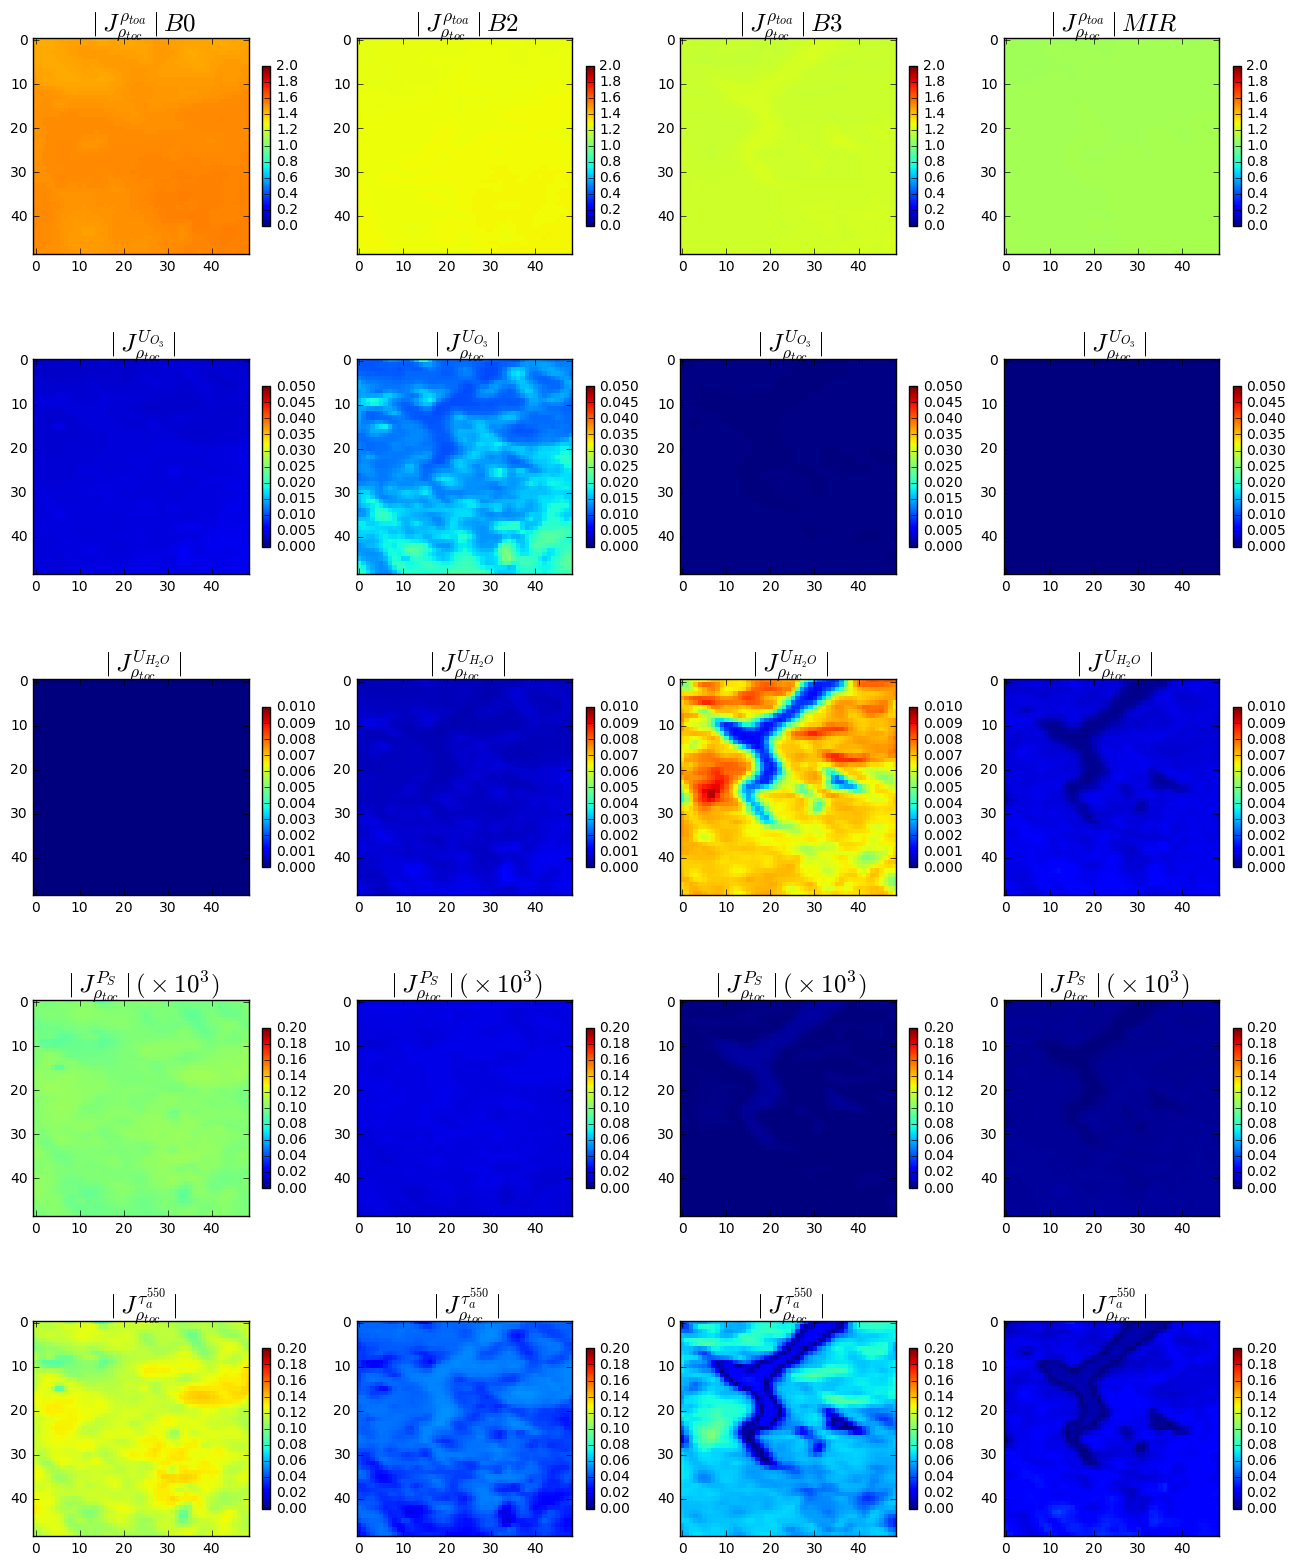

In [27]:
sys.path.append('/home/did/MERIS/BRDF/Fourth_Reprocessing/')
from geoutils.figures import Figures
fig1 = Figures(cols=4, rows=5, size=(4,4), fontsize=18)

for k in range(4): 
    fig1.imshow(Jrtoa[k,:,:],vmin= 0, vmax=2, title=r'$\mid J^{\rho_{toa}}_{\rho_{toc}}\mid ' + tab_band[k] + '$' ,  shrink=0.6, colorbar=True)
for k in range(4): 
    fig1.imshow(Juo3[k,:,:], vmin= 0, vmax=.05, title=r'$\mid J^{U_{O_3}}_{\rho_{toc}}\mid$' ,  shrink=0.6, colorbar=True)
for k in range(4): 
    fig1.imshow(Juh2o[k,:,:], vmin= 0, vmax=.01, title=r'$\mid J^{U_{H_2O}}_{\rho_{toc}}\mid$' ,  shrink=0.6, colorbar=True)
for k in range(4): 
    fig1.imshow(abs(Jpre[k,:,:]*1000), vmin= 0, vmax=0.2, title=r'$\mid J^{P_S}_{\rho_{toc}}\mid (\times 10^3)$' ,  shrink=0.6, colorbar=True)
for k in range(4): 
    fig1.imshow(abs(Jtaup[k,:,:]), vmin= 0, vmax=0.2, title=r'$\mid J ^{\tau_a^{550}}_{\rho_{toc}}\mid$',  shrink=0.6, colorbar=True)

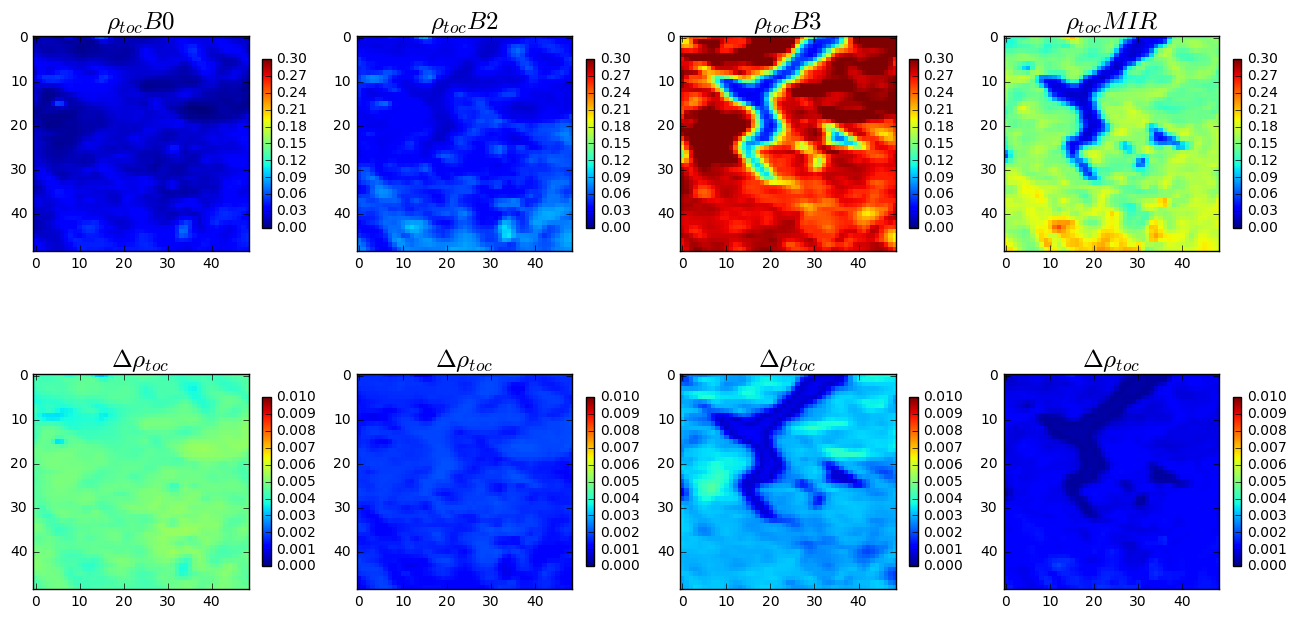

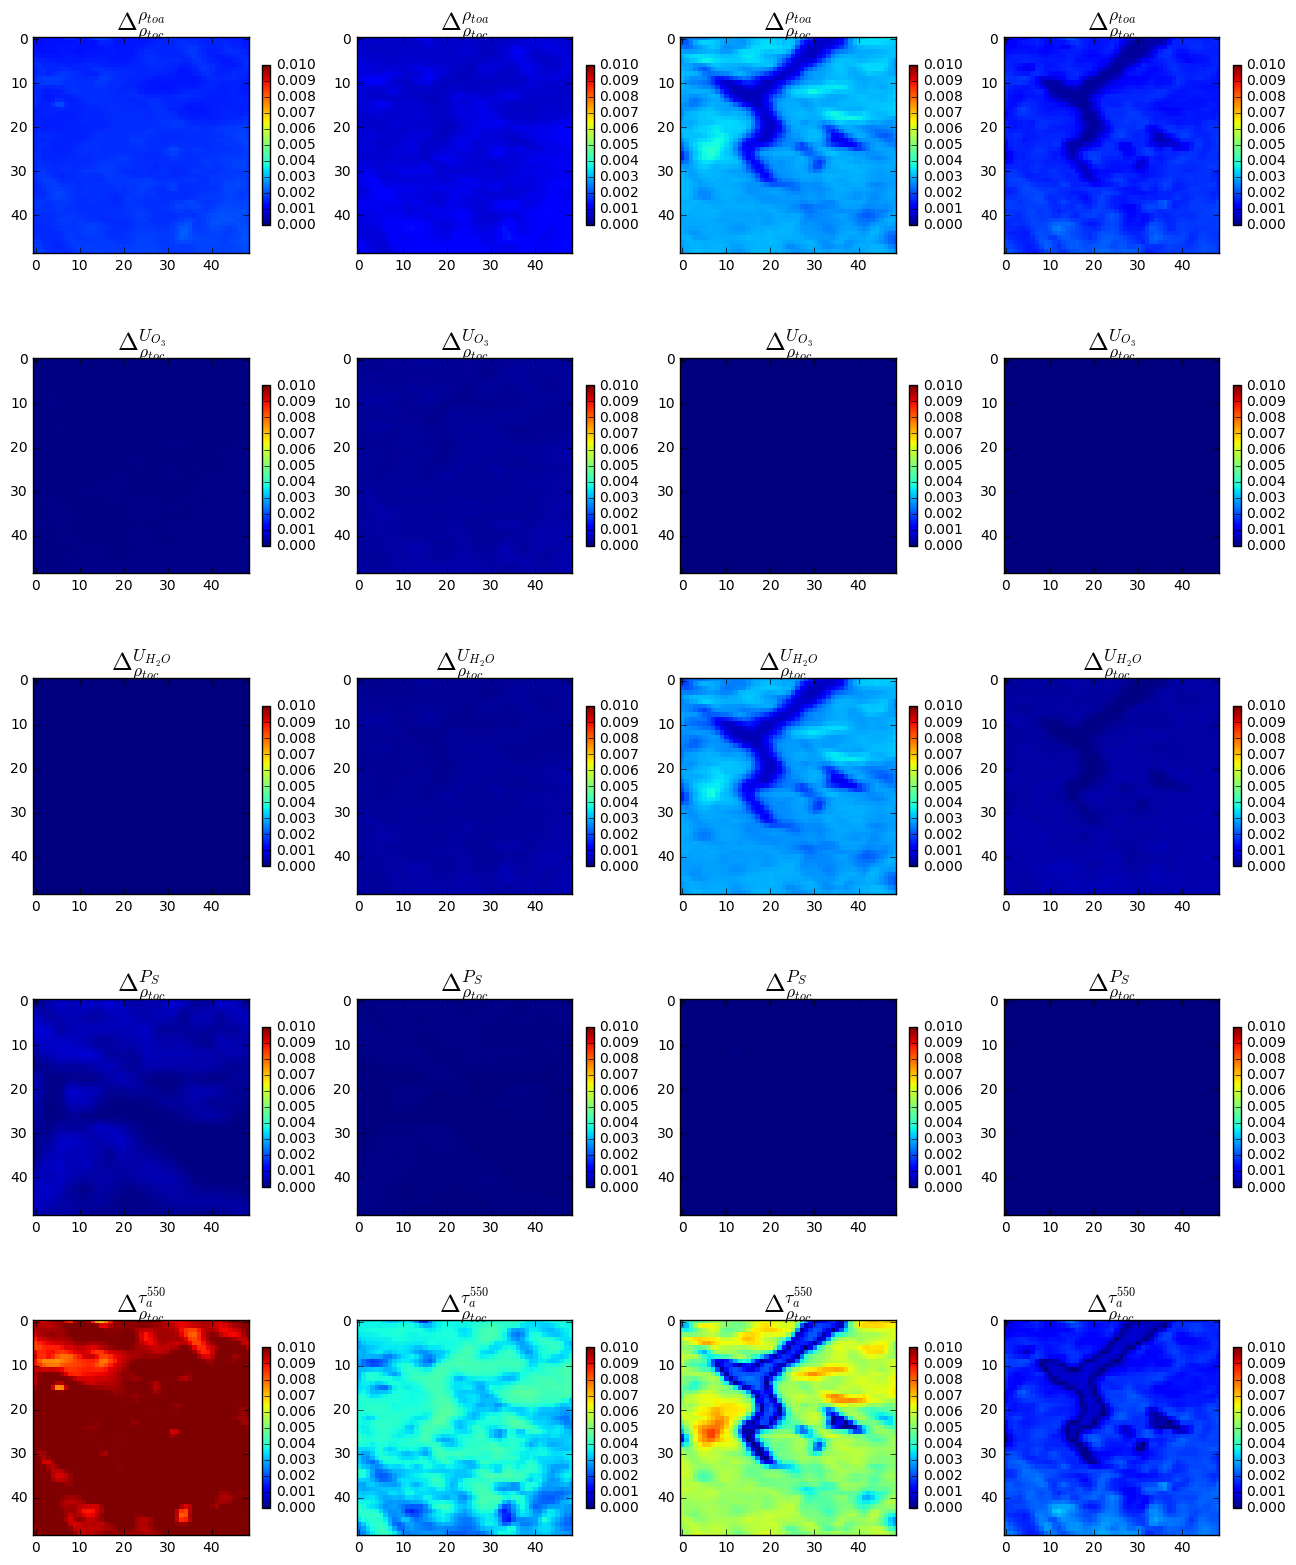

In [34]:
fig2 = Figures(cols=4, rows=2, size=(4,4), fontsize=18)
fig3 = Figures(cols=4, rows=5, size=(4,4), fontsize=18)
vmax = 0.01

for k in range(4):    
    fig2.imshow(rsurf[k,:,:], vmin= 0, vmax=0.3,  title=r'$\rho_{toc} ' + tab_band[k] + '$',  shrink=0.6, colorbar=True)
for k in range(4):    
    fig2.imshow(Drsurf[k,:,:],vmin= 0, vmax=vmax, title=r'$\Delta\rho_{toc}$ ' ,  shrink=0.6, colorbar=True)
for k in range(4): 
    fig3.imshow(Drtoa[k,:,:], vmin= 0, vmax=vmax, title=r'$\Delta^{\rho_{toa}}_{\rho_{toc}}$' ,  shrink=0.6, colorbar=True)
for k in range(4): 
    fig3.imshow(Duo3[k,:,:],  vmin= 0, vmax=vmax, title=r'$\Delta^{U_{O_3}}_{\rho_{toc}}$' ,  shrink=0.6, colorbar=True)
for k in range(4): 
    fig3.imshow(Duh2o[k,:,:], vmin= 0, vmax=vmax, title=r'$\Delta^{U_{H_2O}}_{\rho_{toc}}$' ,  shrink=0.6, colorbar=True)
for k in range(4): 
    fig3.imshow(Dpre[k,:,:],  vmin= 0, vmax=vmax, title=r'$\Delta^{P_S}_{\rho_{toc}} $' ,  shrink=0.6, colorbar=True)
for k in range(4): 
    fig3.imshow(Dtaup[k,:,:], vmin= 0, vmax=vmax, title=r'$\Delta^{\tau_a^{550}}_{\rho_{toc}}$',  shrink=0.6, colorbar=True)

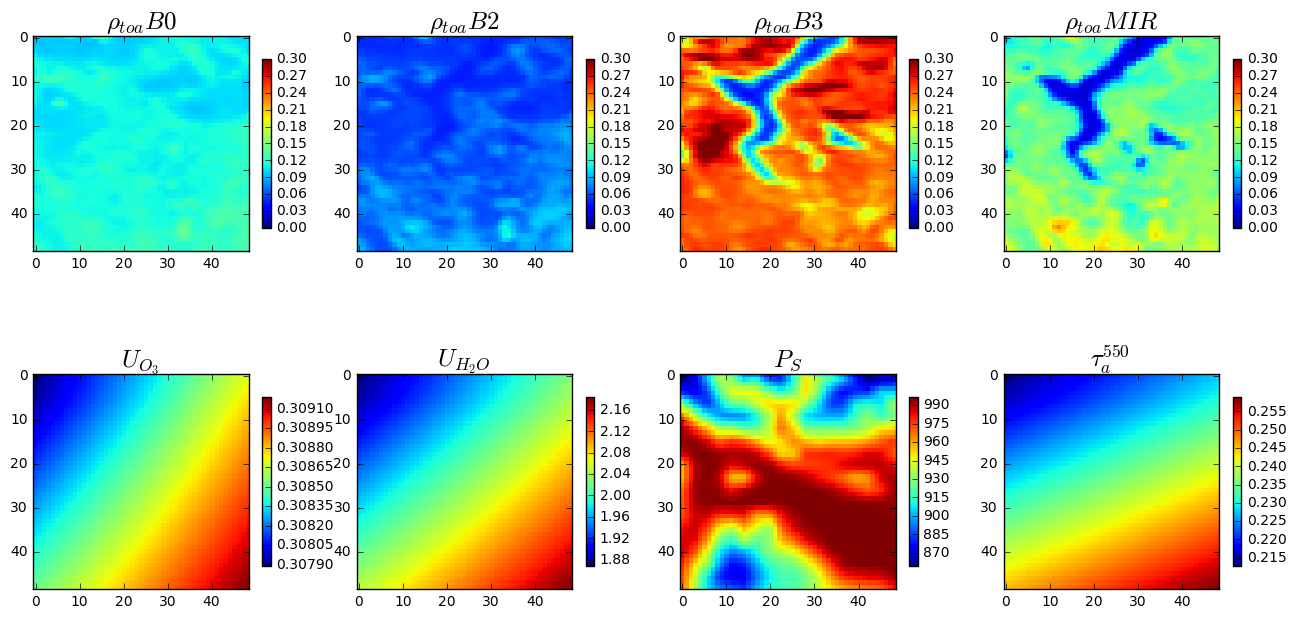

In [26]:
fig3 = Figures(cols=4, rows=2, size=(4,4), fontsize=18)
vmax = 0.01
for k in range(4):    
    fig3.imshow(Irtoa[k,:,:], vmin= 0, vmax=0.3, title=r'$\rho_{toa} ' + tab_band[k] + '$',  shrink=0.6, colorbar=True)
fig3.imshow(Iuo3[:,:],   title=r'$U_{O_3}$ ',   shrink=0.6, colorbar=True)
fig3.imshow(Iuh2o[:,:],  title=r'$U_{H_2O}$ ',  shrink=0.6, colorbar=True)
fig3.imshow(Ipre[:,:],  title=r'$P_{S}$ ',  shrink=0.6, colorbar=True)
fig3.imshow(Itaup[:,:],  title=r'$\tau_a^{550}$ ',  shrink=0.6, colorbar=True)